# Customer Churn Analysis at Fit.ly

## Project Overview

Customer retention is one of the most important challenges for subscription-based businesses. Acquiring new customers is typically more expensive than retaining existing ones, making churn analysis an important component of business strategy.

This project analyzes customer account information, support interactions, user activity, and the available churn information for Fit.ly, a fitness subscription platform.

The analysis combines information from three different data sources:

* Customer account information
* Customer support interactions
* User activity and engagement data

The project focuses on three key business areas:

* User engagement and activity levels
* Customer support experience
* Subscription plan characteristics

## Business Questions

The analysis aims to answer the following questions:

1. What does the available churn data show?
2. How are customers distributed across subscription plans?
3. What are the main customer engagement patterns?
4. What are the main customer support patterns?
5. What metrics should leadership monitor to improve future retention analysis?

The findings provide descriptive insights into customer behavior while also identifying limitations in the available churn data.

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Notebook settings
pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
account_info = pd.read_csv("Data/da_fitly_account_info.csv")
customer_support = pd.read_csv("Data/da_fitly_customer_support.csv")
user_activity = pd.read_csv("Data/da_fitly_user_activity.csv")

In [3]:
datasets = {
    "Account Information": account_info,
    "Customer Support": customer_support,
    "User Activity": user_activity
}

for name, df in datasets.items():

    print("=" * 60)
    print(name)
    print("=" * 60)

    print("\nShape:")
    print(df.shape)

    print("\nFirst Five Rows:")
    display(df.head())

    print("\n")

Account Information

Shape:
(400, 6)

First Five Rows:


,customer_id,email,state,plan,plan_list_price,churn_status
0,C10000,user10000@example.com,New Jersey,Enterprise,105,Y
1,C10001,user10001@example.net,Louisiana,Basic,22,Y
2,C10002,user10002@example.net,Oklahoma,Basic,24,NaN
3,C10003,user10003@example.com,Michigan,Free,0,NaN
4,C10004,user10004@example.com,Texas,Enterprise,119,NaN




Customer Support

Shape:
(918, 7)

First Five Rows:


,ticket_time,user_id,channel,topic,resolution_time_hours,state,comments
0,2025-06-13 05:55:17.154573,10125,chat,technical,11.48,1,NaN
1,2025-08-06 13:21:54.539551,10109,chat,account,1.01,0,NaN
2,2025-08-22 12:39:35.718663,10149,chat,technical,10.09,0,Erase my data from your systems.
3,2025-06-07 02:49:46.986055,10268,phone,account,9.10,1,NaN
4,2025-07-25 00:24:38.945079,10041,phone,other,2.28,1,NaN




User Activity

Shape:
(445, 3)

First Five Rows:


,event_time,user_id,event_type
0,2025-09-08 15:05:39.422721,10118,watch_video
1,2025-09-08 08:15:05.264103,10220,watch_video
2,2025-11-14 06:28:35.207671,10009,share_workout
3,2025-08-20 16:53:38.682901,10227,read_article
4,2025-07-24 16:47:31.728422,10123,track_workout


## Data Validation and Cleaning

Before conducting the analysis, each dataset was validated to identify missing values, duplicate records, incorrect data types, and inconsistencies in categorical variables.

Since the data comes from multiple business functions, standardization was necessary to ensure reliable analysis and accurate insights.

The validation process included:

* Checking dataset dimensions
* Inspecting data types
* Identifying missing values
* Detecting duplicate records
* Standardizing categorical variables
* Converting date columns to datetime format

In [4]:
# Dataset information

for name, df in datasets.items():

    print("=" * 60)
    print(name)
    print("=" * 60)

    print("\nData Types:")
    print(df.dtypes)

    print("\nMissing Values:")
    print(df.isnull().sum())

    print("\nDuplicate Rows:")
    print(df.duplicated().sum())

    print("\n")

Account Information

Data Types:
customer_id        object
email              object
state              object
plan               object
plan_list_price     int64
churn_status       object
dtype: object

Missing Values:
customer_id          0
email                0
state                0
plan                 0
plan_list_price      0
churn_status       286
dtype: int64

Duplicate Rows:
0


Customer Support

Data Types:
ticket_time               object
user_id                    int64
channel                   object
topic                     object
resolution_time_hours    float64
state                      int64
comments                  object
dtype: object

Missing Values:
ticket_time                0
user_id                    0
channel                    0
topic                      0
resolution_time_hours      0
state                      0
comments                 872
dtype: int64

Duplicate Rows:
0


User Activity

Data Types:
event_time    object
user_id        int64
event_type

In [5]:
# ACCOUNT INFO - CLEANING

account_clean = account_info.copy()

# Standardize email addresses
account_clean["email"] = (
    account_clean["email"]
    .str.lower()
    .str.strip()
)

# Standardize state values
account_clean["state"] = (
    account_clean["state"]
    .str.upper()
    .str.strip()
)

# Standardize subscription plan values
account_clean["plan"] = (
    account_clean["plan"]
    .str.strip()
)

# Create numeric user ID
account_clean["user_id"] = (
    account_clean["customer_id"]
    .str.replace("C", "", regex=False)
    .astype(int)
)

# Convert available churn labels to binary values
account_clean["churn"] = (
    account_clean["churn_status"]
    .str.strip()
    .str.upper()
    .map({
        "Y": 1,
        "N": 0
    })
)

account_clean.head()

,customer_id,email,state,plan,plan_list_price,churn_status,user_id,churn
0,C10000,user10000@example.com,NEW JERSEY,Enterprise,105,Y,10000,1.0
1,C10001,user10001@example.net,LOUISIANA,Basic,22,Y,10001,1.0
2,C10002,user10002@example.net,OKLAHOMA,Basic,24,NaN,10002,NaN
3,C10003,user10003@example.com,MICHIGAN,Free,0,NaN,10003,NaN
4,C10004,user10004@example.com,TEXAS,Enterprise,119,NaN,10004,NaN


In [6]:
# CHECK CHURN STATUS DISTRIBUTION

print("Unique churn_status values:")
print(account_clean["churn_status"].unique())

print("\nChurn status counts:")
print(account_clean["churn_status"].value_counts(dropna=False))

print("\nChurn status percentages:")
print(
    account_clean["churn_status"]
    .value_counts(dropna=False, normalize=True)
    .mul(100)
)

Unique churn_status values:
['Y' nan]

Churn status counts:
churn_status
NaN    286
Y      114
Name: count, dtype: int64

Churn status percentages:
churn_status
NaN    71.5
Y      28.5
Name: proportion, dtype: float64


In [7]:
# CUSTOMER SUPPORT - CLEANING AND AGGREGATION

support_clean = customer_support.copy()

# Convert ticket timestamps to datetime
support_clean["ticket_time"] = pd.to_datetime(
    support_clean["ticket_time"],
    errors="coerce"
)

# Standardize support channel values
support_clean["channel"] = (
    support_clean["channel"]
    .str.lower()
    .str.strip()
)

# Standardize support topic values
support_clean["topic"] = (
    support_clean["topic"]
    .str.lower()
    .str.strip()
)

# Aggregate support information by customer
support_summary = (
    support_clean
    .groupby("user_id")
    .agg(
        total_tickets=("ticket_time", "count"),
        avg_resolution_hours=("resolution_time_hours", "mean")
    )
    .reset_index()
)

print(
    "Invalid ticket dates:",
    support_clean["ticket_time"].isna().sum()
)

support_summary.head()

Invalid ticket dates: 0


,user_id,total_tickets,avg_resolution_hours
0,10000,3,21.446667
1,10001,4,17.542500
2,10002,3,6.433333
3,10003,1,2.190000
4,10004,4,8.542500


In [8]:
# USER ACTIVITY - CLEANING AND AGGREGATION

activity_clean = user_activity.copy()

# Convert event timestamps to datetime
activity_clean["event_time"] = pd.to_datetime(
    activity_clean["event_time"],
    errors="coerce"
)

# Standardize event type values
activity_clean["event_type"] = (
    activity_clean["event_type"]
    .str.lower()
    .str.strip()
)

# Aggregate activity by customer
activity_summary = (
    activity_clean
    .groupby("user_id")
    .agg(
        total_activities=("event_type", "count")
    )
    .reset_index()
)

print(
    "Invalid activity dates:",
    activity_clean["event_time"].isna().sum()
)

activity_clean.head()

Invalid activity dates: 0


,event_time,user_id,event_type
0,2025-09-08 15:05:39.422721,10118,watch_video
1,2025-09-08 08:15:05.264103,10220,watch_video
2,2025-11-14 06:28:35.207671,10009,share_workout
3,2025-08-20 16:53:38.682901,10227,read_article
4,2025-07-24 16:47:31.728422,10123,track_workout


In [9]:
# MERGE ALL DATASETS

df = (
    account_clean
    .merge(
        support_summary,
        on="user_id",
        how="left"
    )
    .merge(
        activity_summary,
        on="user_id",
        how="left"
    )
)

df.head()

,customer_id,email,state,plan,plan_list_price,churn_status,user_id,churn,total_tickets,avg_resolution_hours,total_activities
0,C10000,user10000@example.com,NEW JERSEY,Enterprise,105,Y,10000,1.0,3.0,21.446667,3.0
1,C10001,user10001@example.net,LOUISIANA,Basic,22,Y,10001,1.0,4.0,17.542500,1.0
2,C10002,user10002@example.net,OKLAHOMA,Basic,24,NaN,10002,NaN,3.0,6.433333,1.0
3,C10003,user10003@example.com,MICHIGAN,Free,0,NaN,10003,NaN,1.0,2.190000,1.0
4,C10004,user10004@example.com,TEXAS,Enterprise,119,NaN,10004,NaN,4.0,8.542500,4.0


In [10]:
# HANDLE MISSING AGGREGATED VALUES

df["total_tickets"] = df["total_tickets"].fillna(0)

df["total_activities"] = df["total_activities"].fillna(0)

df.head()

,customer_id,email,state,plan,plan_list_price,churn_status,user_id,churn,total_tickets,avg_resolution_hours,total_activities
0,C10000,user10000@example.com,NEW JERSEY,Enterprise,105,Y,10000,1.0,3.0,21.446667,3.0
1,C10001,user10001@example.net,LOUISIANA,Basic,22,Y,10001,1.0,4.0,17.542500,1.0
2,C10002,user10002@example.net,OKLAHOMA,Basic,24,NaN,10002,NaN,3.0,6.433333,1.0
3,C10003,user10003@example.com,MICHIGAN,Free,0,NaN,10003,NaN,1.0,2.190000,1.0
4,C10004,user10004@example.com,TEXAS,Enterprise,119,NaN,10004,NaN,4.0,8.542500,4.0


In [11]:
# CHECK FINAL DATASET

print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isna().sum())

Shape: (400, 11)

Columns:
['customer_id', 'email', 'state', 'plan', 'plan_list_price', 'churn_status', 'user_id', 'churn', 'total_tickets', 'avg_resolution_hours', 'total_activities']

Missing Values:
customer_id               0
email                     0
state                     0
plan                      0
plan_list_price           0
churn_status            286
user_id                   0
churn                   286
total_tickets             0
avg_resolution_hours     33
total_activities          0
dtype: int64


In [24]:
# CREATE DATASET WITH KNOWN CHURN STATUS

churn_df = df.dropna(subset=["churn"]).copy()

print("Churn dataset shape:", churn_df.shape)

print("\nChurn counts:")
print(churn_df["churn"].value_counts())

print("\nChurn percentages:")
print(churn_df["churn"].value_counts(normalize=True) * 100)

Churn dataset shape: (114, 11)

Churn counts:
churn
1.0    114
Name: count, dtype: int64

Churn percentages:
churn
1.0    100.0
Name: proportion, dtype: float64


## Validation Summary

### Account Information

* Standardized email addresses to lowercase.
* Standardized state and subscription plan values.
* Converted available churn values into binary format for analysis.
* Identified substantial missing churn information: 286 of 400 customers (71.5%) have no recorded churn status.

### Customer Support

* Converted ticket timestamps into datetime format.
* Standardized support channels and issue topics.
* Aggregated support tickets and average resolution time by customer.

### User Activity

* Converted event timestamps into datetime format.
* Standardized activity event categories.
* Aggregated customer activity by user.

### Data Quality Limitation

A significant limitation was identified in the churn data.

Only 114 of the 400 customers have a recorded churn status, and every recorded status is classified as churned. No customers are explicitly identified as retained.

Therefore, the available data cannot support reliable comparisons between churned and retained customers.

## Exploratory Data Analysis (EDA)

The objective of this exploratory analysis is to understand customer behavior, engagement, support activity, subscription characteristics, and the limitations of the available churn data.

The analysis focuses on:

* Available churn information
* Subscription plans
* Customer engagement
* Support interactions
* Relationships between business metrics

### Available Churn Information

Churn information is available for 114 of the 400 customers in the dataset.

Among customers with a recorded churn status, the observed churn rate is 100%. However, this result should be interpreted with caution because churn information is missing for 286 customers and there are no explicitly retained customers in the available churn data.

Therefore, the 100% rate should not be interpreted as the true churn rate of the entire Fit.ly customer base.

In [13]:
# Calculate observed churn rate among customers with known churn status

observed_churn_rate = churn_df["churn"].mean() * 100

print(
    f"Observed Churn Rate Among Known Statuses: "
    f"{observed_churn_rate:.2f}%"
)

Observed Churn Rate Among Known Statuses: 100.00%


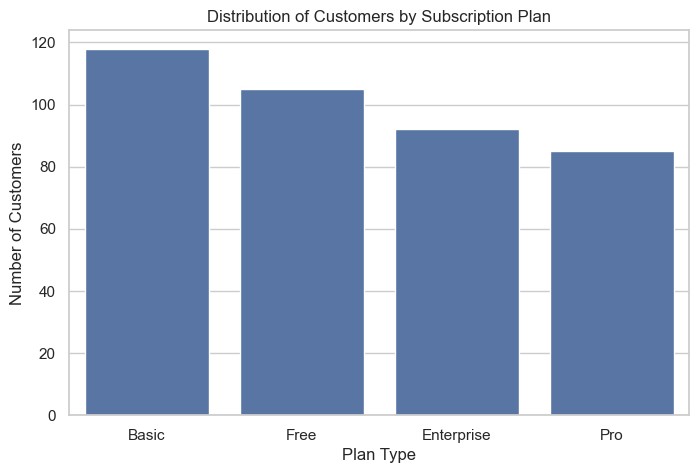

In [14]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=account_clean,
    x="plan",
    order=account_clean["plan"].value_counts().index
)

plt.title("Distribution of Customers by Subscription Plan")
plt.xlabel("Plan Type")
plt.ylabel("Number of Customers")

plt.show()

### Subscription Plan Distribution

Understanding how customers are distributed across subscription plans provides a descriptive view of the Fit.ly customer base.

Differences in customer volume across plans may also help identify customer segments for future retention analysis once complete churn information becomes available.

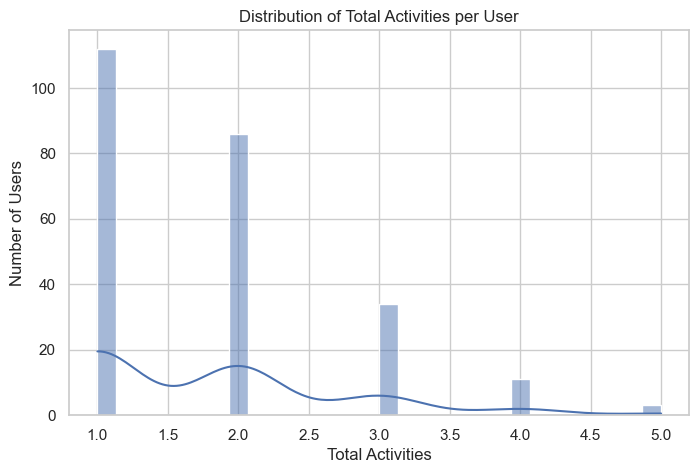

In [15]:
# Distribution of total activities per user

plt.figure(figsize=(8, 5))

sns.histplot(
    data=activity_summary,
    x="total_activities",
    bins=30,
    kde=True
)

plt.title("Distribution of Total Activities per User")
plt.xlabel("Total Activities")
plt.ylabel("Number of Users")

plt.show()

### Customer Engagement

Customer activity levels vary across the Fit.ly user base.

Analyzing the distribution of total activities helps identify highly engaged and low-engagement customers. Low activity may represent an important segment for future retention analysis.

However, because the available churn data does not include retained customers, the current dataset cannot establish whether lower engagement is associated with higher churn.

In [16]:
# Average customer activity by subscription plan

activity_by_plan = (
    df
    .groupby("plan")["total_activities"]
    .mean()
    .sort_values(ascending=False)
)

activity_by_plan

plan
Enterprise    1.260870
Basic         1.220339
Pro           1.023529
Free          0.933333
Name: total_activities, dtype: float64

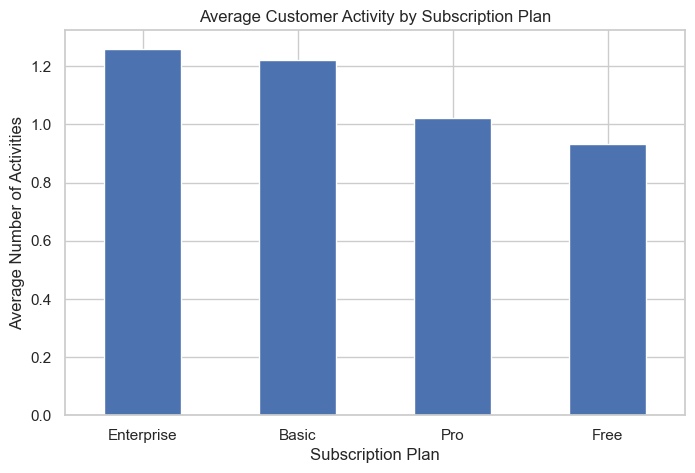

In [17]:
plt.figure(figsize=(8, 5))

activity_by_plan.plot(kind="bar")

plt.title("Average Customer Activity by Subscription Plan")
plt.xlabel("Subscription Plan")
plt.ylabel("Average Number of Activities")
plt.xticks(rotation=0)

plt.show()

### Customer Engagement by Subscription Plan

Customer activity varies across subscription plans.

This comparison provides a descriptive view of engagement across customer segments using the complete customer dataset.

Because no retained customer group is available, these engagement differences cannot currently be interpreted as drivers of churn.

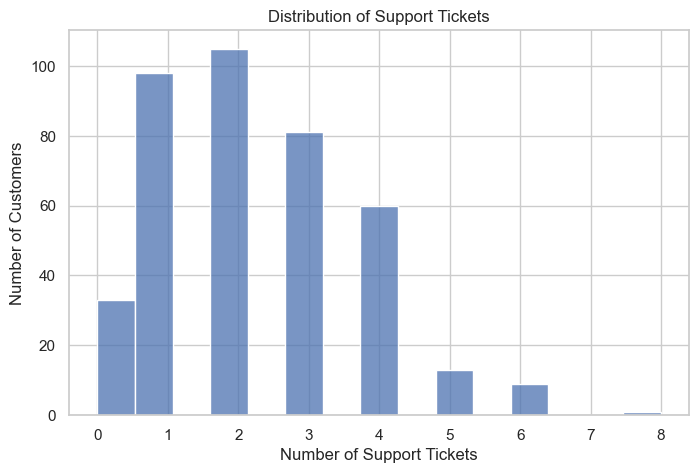

In [18]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="total_tickets",
    bins=15
)

plt.title("Distribution of Support Tickets")
plt.xlabel("Number of Support Tickets")
plt.ylabel("Number of Customers")

plt.show()

In [19]:
# Average support tickets by subscription plan

support_by_plan = (
    df
    .groupby("plan")["total_tickets"]
    .mean()
    .sort_values(ascending=False)
)

support_by_plan

plan
Basic         2.347458
Free          2.342857
Pro           2.329412
Enterprise    2.141304
Name: total_tickets, dtype: float64

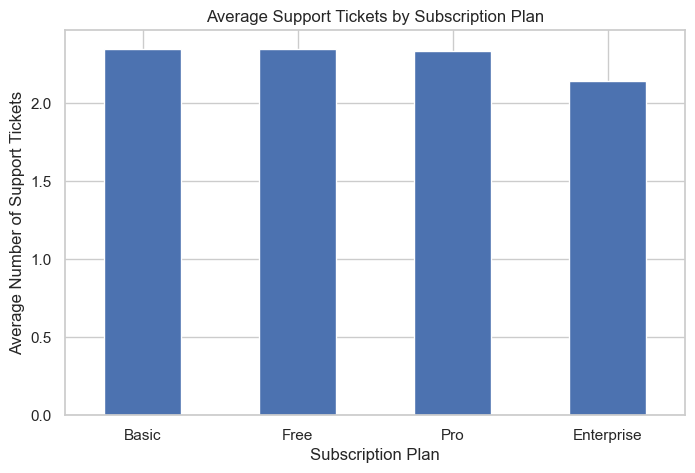

In [20]:
plt.figure(figsize=(8, 5))

support_by_plan.plot(kind="bar")

plt.title("Average Support Tickets by Subscription Plan")
plt.xlabel("Subscription Plan")
plt.ylabel("Average Number of Support Tickets")
plt.xticks(rotation=0)

plt.show()

### Customer Support Analysis

Across the full customer dataset, customers generated an average of approximately 2.29 support tickets, with an average resolution time of approximately 10.23 hours.

Support activity also varies across subscription plans, providing a descriptive view of customer service demand across customer segments.

However, because the available churn data does not contain explicitly retained customers, the analysis cannot determine whether support activity or resolution time is associated with churn.

## Correlation Analysis

A correlation analysis was performed to explore relationships among numerical customer metrics, including subscription value, support activity, resolution time, and customer engagement.

Churn was excluded because all customers with a known churn status belong to the same class, making a meaningful churn correlation impossible to estimate.

In [21]:
# Select numerical business variables

numerical_columns = [
    "plan_list_price",
    "total_tickets",
    "avg_resolution_hours",
    "total_activities"
]

# Calculate correlation matrix using the full customer dataset
correlation_matrix = df[numerical_columns].corr()

correlation_matrix

,plan_list_price,total_tickets,avg_resolution_hours,total_activities
plan_list_price,1.000000,-0.066163,-0.069295,0.077398
total_tickets,-0.066163,1.000000,0.047420,-0.001965
avg_resolution_hours,-0.069295,0.047420,1.000000,-0.317400
total_activities,0.077398,-0.001965,-0.317400,1.000000


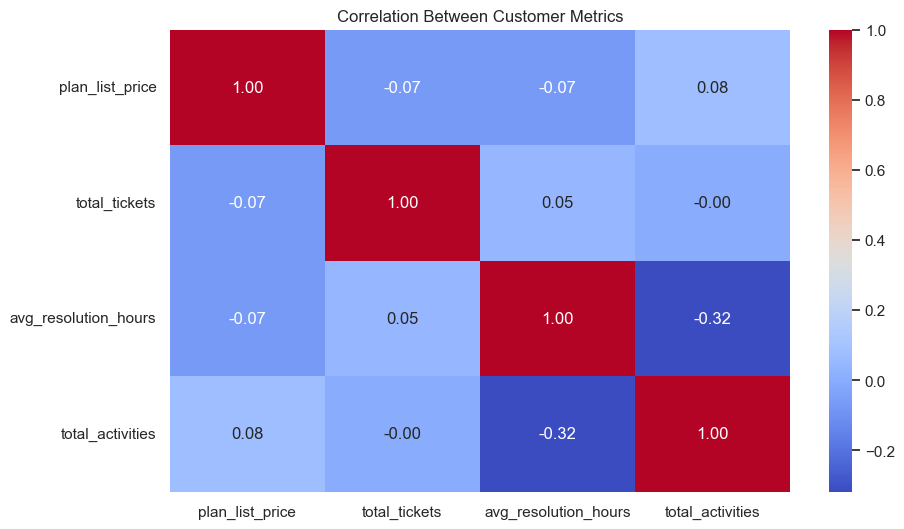

In [22]:
plt.figure(figsize=(10,6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between Customer Metrics")

plt.show()

### Correlation Insights

The numerical customer metrics show generally weak linear relationships.

No strong correlation was observed among subscription price, support activity, resolution time, and customer activity.

Churn was excluded from the correlation analysis because all customers with a recorded churn status belong to the same class.

A more complete dataset containing both churned and retained customers would be required to analyze potential churn drivers.

## Business Metrics

Fit.ly should monitor a small set of customer behavior, support, and data-quality metrics.

These metrics provide useful baseline information and can support future retention analysis once more complete churn-status information becomes available.

In [23]:
# Business Metrics

# Average activity across all customers
avg_activities = df["total_activities"].mean()

# Average support tickets per customer
avg_tickets = df["total_tickets"].mean()

# Average support resolution time
avg_resolution = df["avg_resolution_hours"].mean()

# Percentage of customers with known churn status
known_churn_percentage = (
    df["churn"].notna().mean() * 100
)

# Display key business metrics
print(
    f"Observed Churn Rate Among Known Statuses: "
    f"{observed_churn_rate:.2f}%"
)

print(
    f"Customers With Known Churn Status: "
    f"{known_churn_percentage:.2f}%"
)

print(f"Average Customer Activity: {avg_activities:.2f}")
print(f"Average Support Tickets: {avg_tickets:.2f}")
print(f"Average Resolution Time: {avg_resolution:.2f} hours")

Observed Churn Rate Among Known Statuses: 100.00%
Customers With Known Churn Status: 28.50%
Average Customer Activity: 1.11
Average Support Tickets: 2.29
Average Resolution Time: 10.23 hours


### Recommended Business KPIs

Based on the available data, Fit.ly should monitor:

1. Percentage of Customers With Known Churn Status
2. Average Customer Activity
3. Average Support Tickets per Customer
4. Average Support Resolution Time
5. Customer Distribution by Subscription Plan

Once complete churn data becomes available, Fit.ly should also monitor:

* Overall Churn Rate
* Churn Rate by Subscription Plan
* Churn Rate by Engagement Level
* Churn Rate by Support Experience

## Recommendations

The analysis provides useful descriptive information about customer activity, support interactions, and subscription plans. However, the incomplete churn data limits the ability to identify specific drivers of customer attrition.

The following actions are recommended for further analysis and retention management.

### Recommendation 1: Investigate Low-Engagement Customers

Fit.ly should identify customers with low activity and evaluate whether they are more likely to disengage or cancel once complete churn data becomes available.

### Recommendation 2: Strengthen Customer Onboarding

Fit.ly could test personalized onboarding experiences, tutorials, and reminders to determine whether these interventions increase customer engagement.

### Recommendation 3: Monitor Support Performance

Support resolution time should continue to be monitored as an important customer-experience metric.

Once complete churn data becomes available, Fit.ly should evaluate whether longer resolution times are associated with higher churn.

### Recommendation 4: Compare Retention Across Subscription Plans

Future analysis should compare churn rates across subscription plans once both churned and retained customers are available.

### Recommendation 5: Implement Retention Dashboards

Leadership should monitor customer engagement, support activity, churn-data completeness, and eventually churn trends through a centralized dashboard.

# Final Conclusion

This analysis combined customer account information, support interactions, and user activity data to explore customer behavior at Fit.ly and evaluate the available churn information.

The analysis identified useful baseline metrics, including an average customer activity level of approximately 1.11 activities, an average of 2.29 support tickets per customer, and an average support resolution time of approximately 10.23 hours.

A significant limitation was identified in the churn data. Churn status is available for only 114 of the 400 customers (28.5%), and all customers with a known status are classified as churned.

As a result, the observed 100% churn rate among known statuses cannot be considered representative of the entire customer base. Reliable comparisons between churned and retained customers cannot currently be performed.

The analysis therefore provides descriptive insights into customer engagement, support activity, subscription behavior, and data quality.

Future analysis should include complete churn information for both retained and churned customers. This would allow Fit.ly to calculate a reliable overall churn rate, identify churn drivers, compare retention across subscription plans, and eventually develop predictive models to identify customers at risk of leaving.